In [17]:
# ET_proj_analysis.py
# copyright@pifuyuini
# 仅供实验小组成员使用

# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 绘图设置
# 风格
plt.style.use('seaborn-v0_8-whitegrid')
# 全局设置
config = {'font.family':'Times New Roman', 'figure.dpi':500, 'figure.figsize':(10,8), 'axes.labelsize':20}
plt.rcParams.update(config)
# 配色
from matplotlib.colors import LinearSegmentedColormap
colors = ['#3e324a', '#475d7b', '#97c6c0', '#e26e1b', '#4df8e8'] # FireFly!
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# 其它
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

In [18]:
# 加载数据
data = pd.read_csv('10 35.csv')
time = data['Time(s)'].values
ch1 = data['CH1(V)'].values
ch2 = data['CH2(V)'].values

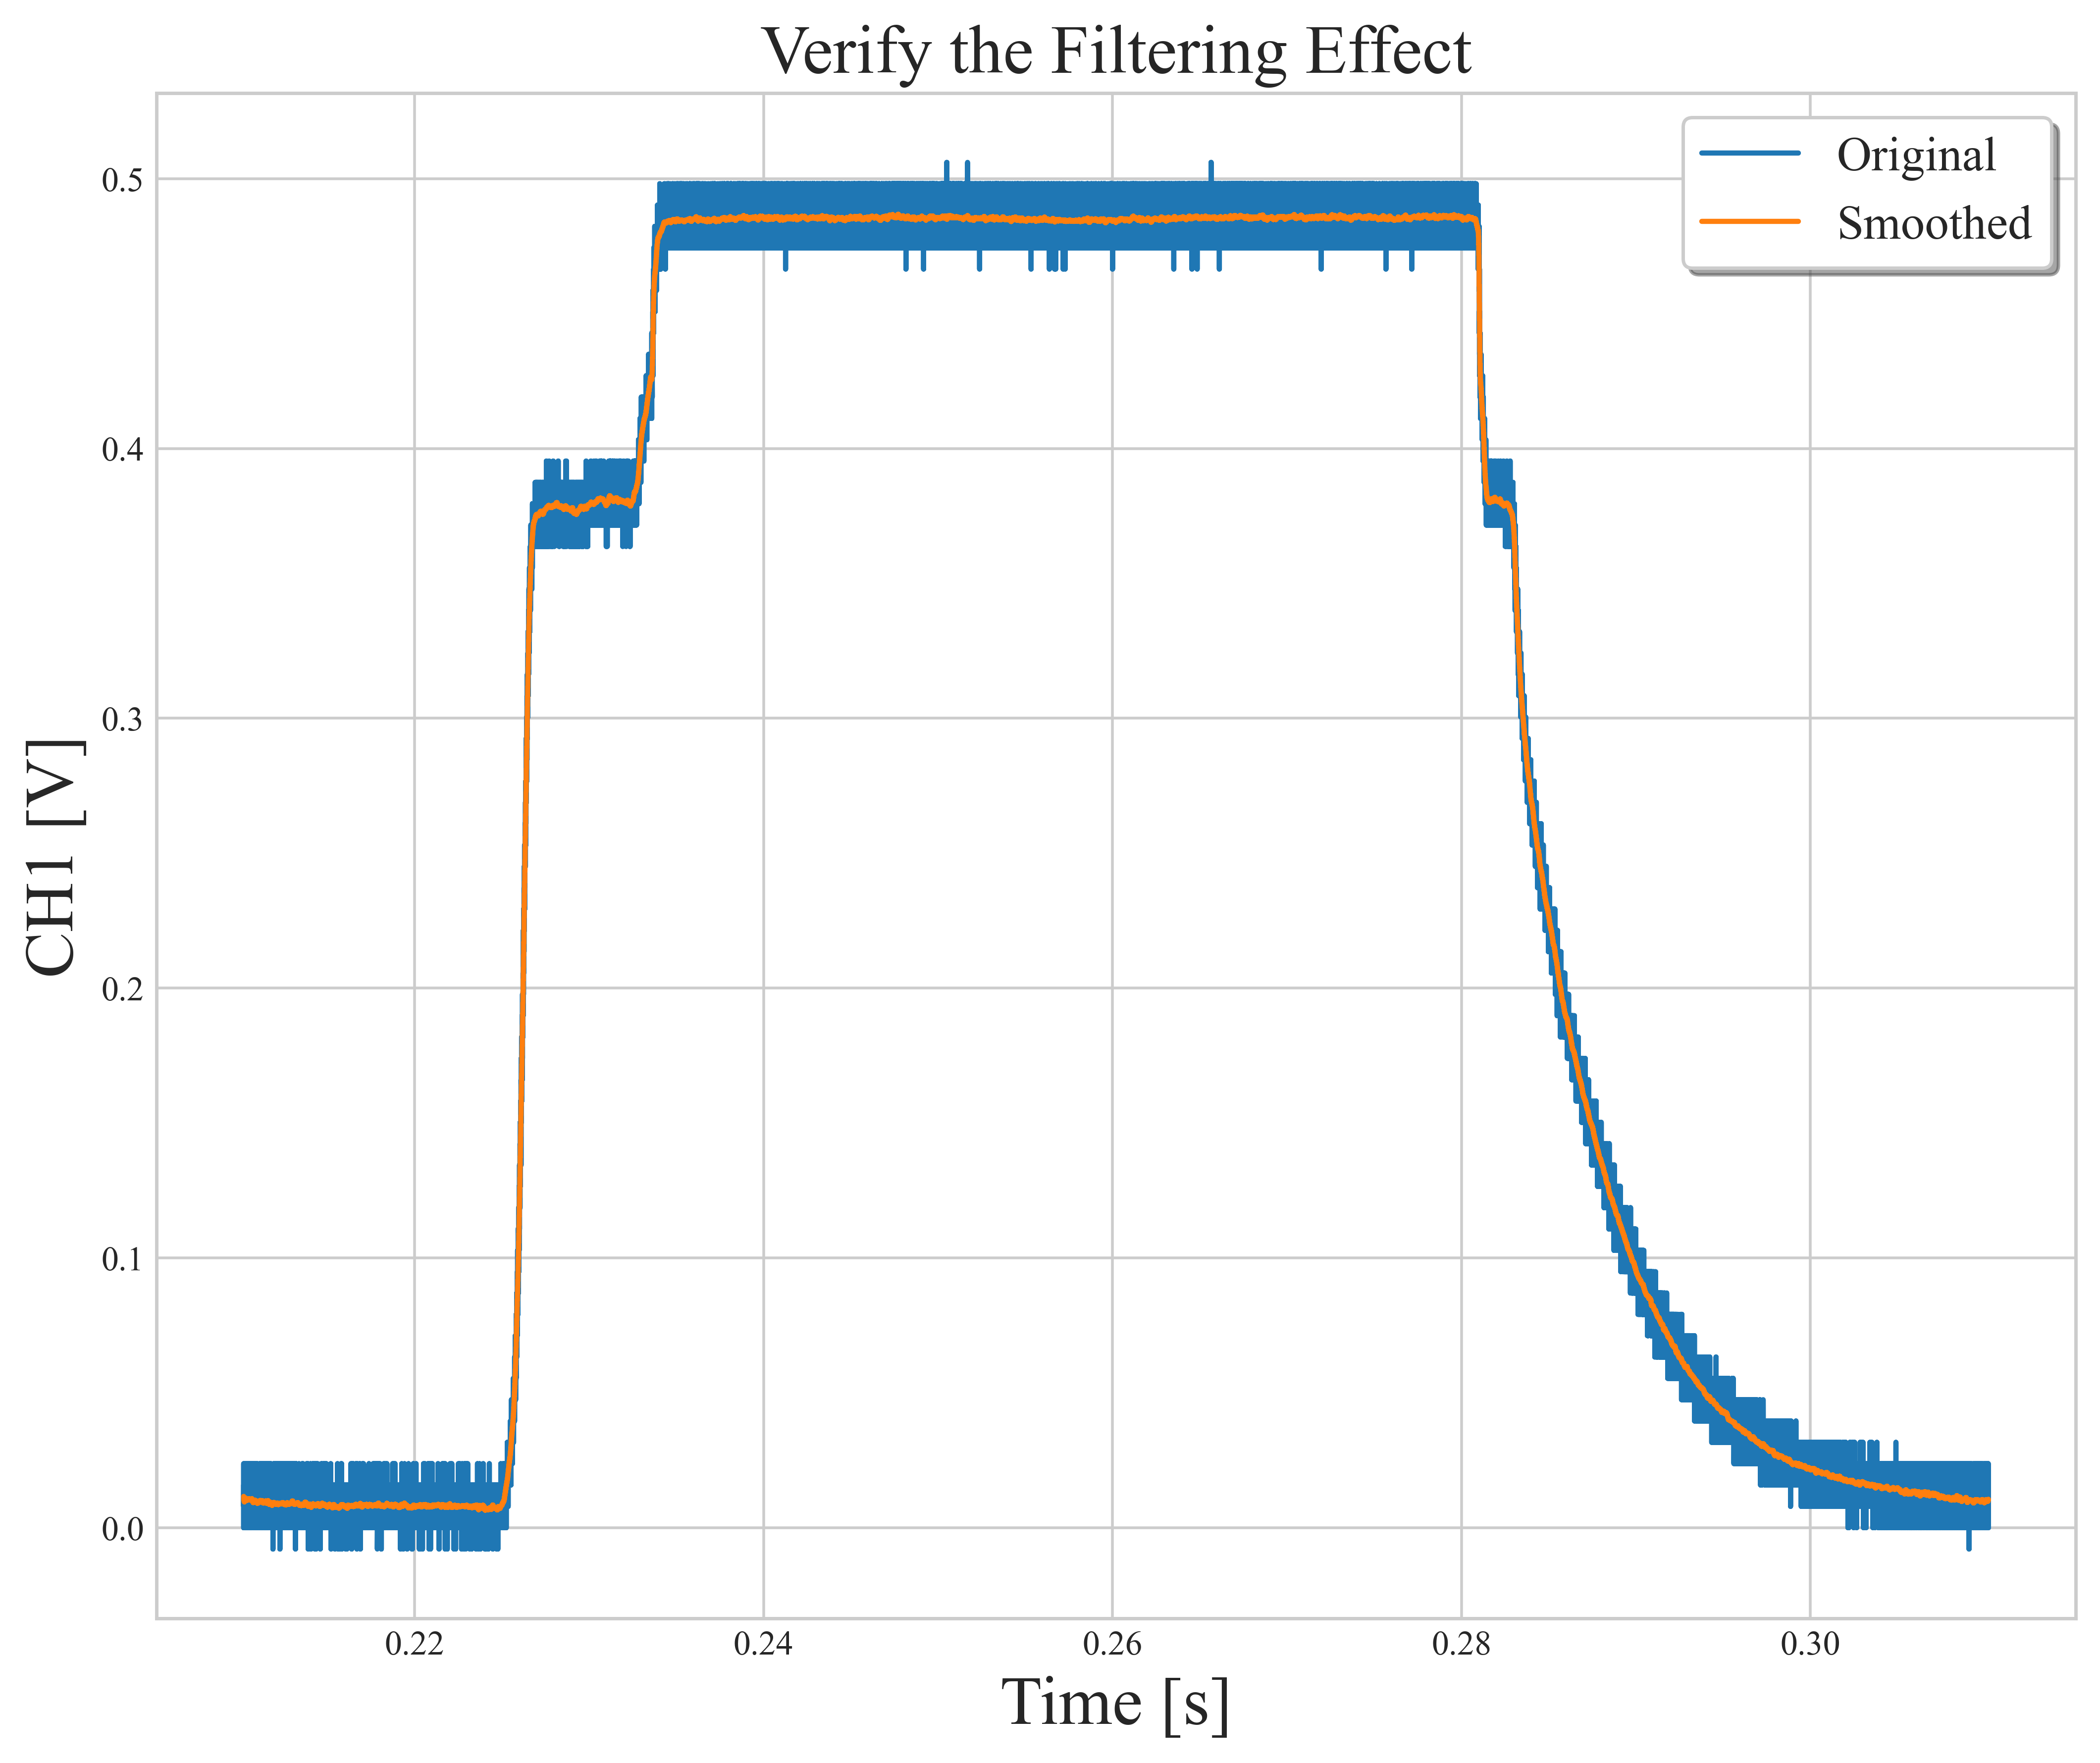

In [21]:
# 滤波
window_length = 1511  # 窗口长度，可以根据实际情况调整
polyorder = 3       # 多项式阶数，一般为2或3
smoothed_ch1 = savgol_filter(ch1, window_length, polyorder)
smoothed_ch2 = savgol_filter(ch2, window_length, polyorder)

# 验证滤波效果
plt.figure()
plt.plot(time, ch2, label='Original')
plt.plot(time, smoothed_ch2, label='Smoothed')
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.title("Verify the Filtering Effect", fontsize=20)
plt.xlabel('Time [s]')
plt.ylabel("CH1 [V]")
plt.show()

In [ ]:
# 测试数据处理效果
CH1 = smoothed_ch1
CH2 = smoothed_ch2

# 定义拟合函数（用来拟合平稳区域的高低电平值）
def flat_line(x, a):
    return a * np.ones_like(x)

# 找到 CH1 左右跃变点
CH1_threshold = (np.max(CH1) + np.min(CH1)) / 2  # 动态阈值
CH1_left_index = np.where((CH1[:-1] < CH1_threshold) & (CH1[1:] > CH1_threshold))[0][0]
CH1_right_index = np.where((CH1[:-1] > CH1_threshold) & (CH1[1:] < CH1_threshold))[0][0]
CH1_left_time = time[CH1_left_index]
CH1_right_time = time[CH1_right_index]

# 拟合 CH2 信号高低电平值
high_indices = np.where(CH2 > (np.max(CH2) + np.min(CH2)) / 2)[0]
low_indices = np.where(CH2 < (np.max(CH2) + np.min(CH2)) / 2)[0]

# 高电平拟合
popt_high, _ = curve_fit(flat_line, time[high_indices], CH2[high_indices])
CH2_high_level = popt_high[0]

# 低电平拟合
popt_low, _ = curve_fit(flat_line, time[low_indices], CH2[low_indices])
CH2_low_level = popt_low[0]

# 找到 CH2 的下降开始时间
CH2_fall_start_index = np.where((CH2[:-1] > CH2_high_level) & (CH2[1:] < CH2_high_level))[0][0]
CH2_fall_start_time = time[CH2_fall_start_index]

# 找到停止下降和开始上升时间点：通过低电平拟合直线与信号曲线交点
# 交点的计算方法
def find_intersection(x, y, level):
    """找到信号 y 与水平线 level 的交点"""
    intersections = []
    for i in range(len(y) - 1):
        if (y[i] > level and y[i + 1] < level) or (y[i] < level and y[i + 1] > level):
            # 线性插值计算交点
            t = (level - y[i]) / (y[i + 1] - y[i])
            intersection_time = x[i] + t * (x[i + 1] - x[i])
            intersections.append(intersection_time)
    return intersections

# 找低电平交点
low_intersections = find_intersection(time, CH2, CH2_low_level)

# 确定停止下降和开始上升的时间点
if len(low_intersections) >= 2:
    CH2_rise_start_time = low_intersections[0]  # 第一个交点为停止下降时间点
    CH2_fall_end_time = low_intersections[1]  # 第二个交点为开始上升时间点
else:
    raise ValueError("未找到低电平的两个交点，请检查数据质量")

# 计算下降时间和上升时间
CH2_fall_duration = CH2_fall_end_time - CH2_fall_start_time

# 找到 CH2 上升结束时间
CH2_rise_end_index = np.where((CH2[:-1] < CH2_high_level) & (CH2[1:] > CH2_high_level))[0][0]
CH2_rise_end_time = time[CH2_rise_end_index]
CH2_rise_duration = CH2_rise_end_time - CH2_rise_start_time

# 计算响应时间
rise_response_time = CH2_rise_start_time - CH1_left_time
fall_response_time = CH2_fall_start_time - CH1_right_time

# 输出结果
print("CH1 左跃变时间:", CH1_left_time)
print("CH1 右跃变时间:", CH1_right_time)
print()
print("CH2 高电平:", CH2_high_level)
print("CH2 低电平:", CH2_low_level)
print()
print("CH2 下降开始时间:", CH2_fall_start_time)
print("CH2 下降结束时间:", CH2_fall_end_time)
print("CH2 下降时间:", CH2_fall_duration)
print()
print("CH2 上升开始时间:", CH2_rise_start_time)
print("CH2 上升结束时间:", CH2_rise_end_time)
print("CH2 上升时间:", CH2_rise_duration)
print()
print("上升响应时间:", rise_response_time)
print("下降响应时间:", fall_response_time)

CH1 左跃变时间: 0.21946
CH1 右跃变时间: 0.26946

CH2 高电平: 0.4634966367664075
CH2 低电平: 0.04125372974929564

CH2 下降开始时间: 0.28101
CH2 下降结束时间: 0.29526
CH2 下降时间: 0.01425000000000004

CH2 上升开始时间: 0.22566
CH2 上升结束时间: 0.23375
CH2 上升时间: 0.008090000000000014

上升响应时间: 0.006200000000000011
下降响应时间: 0.011550000000000005


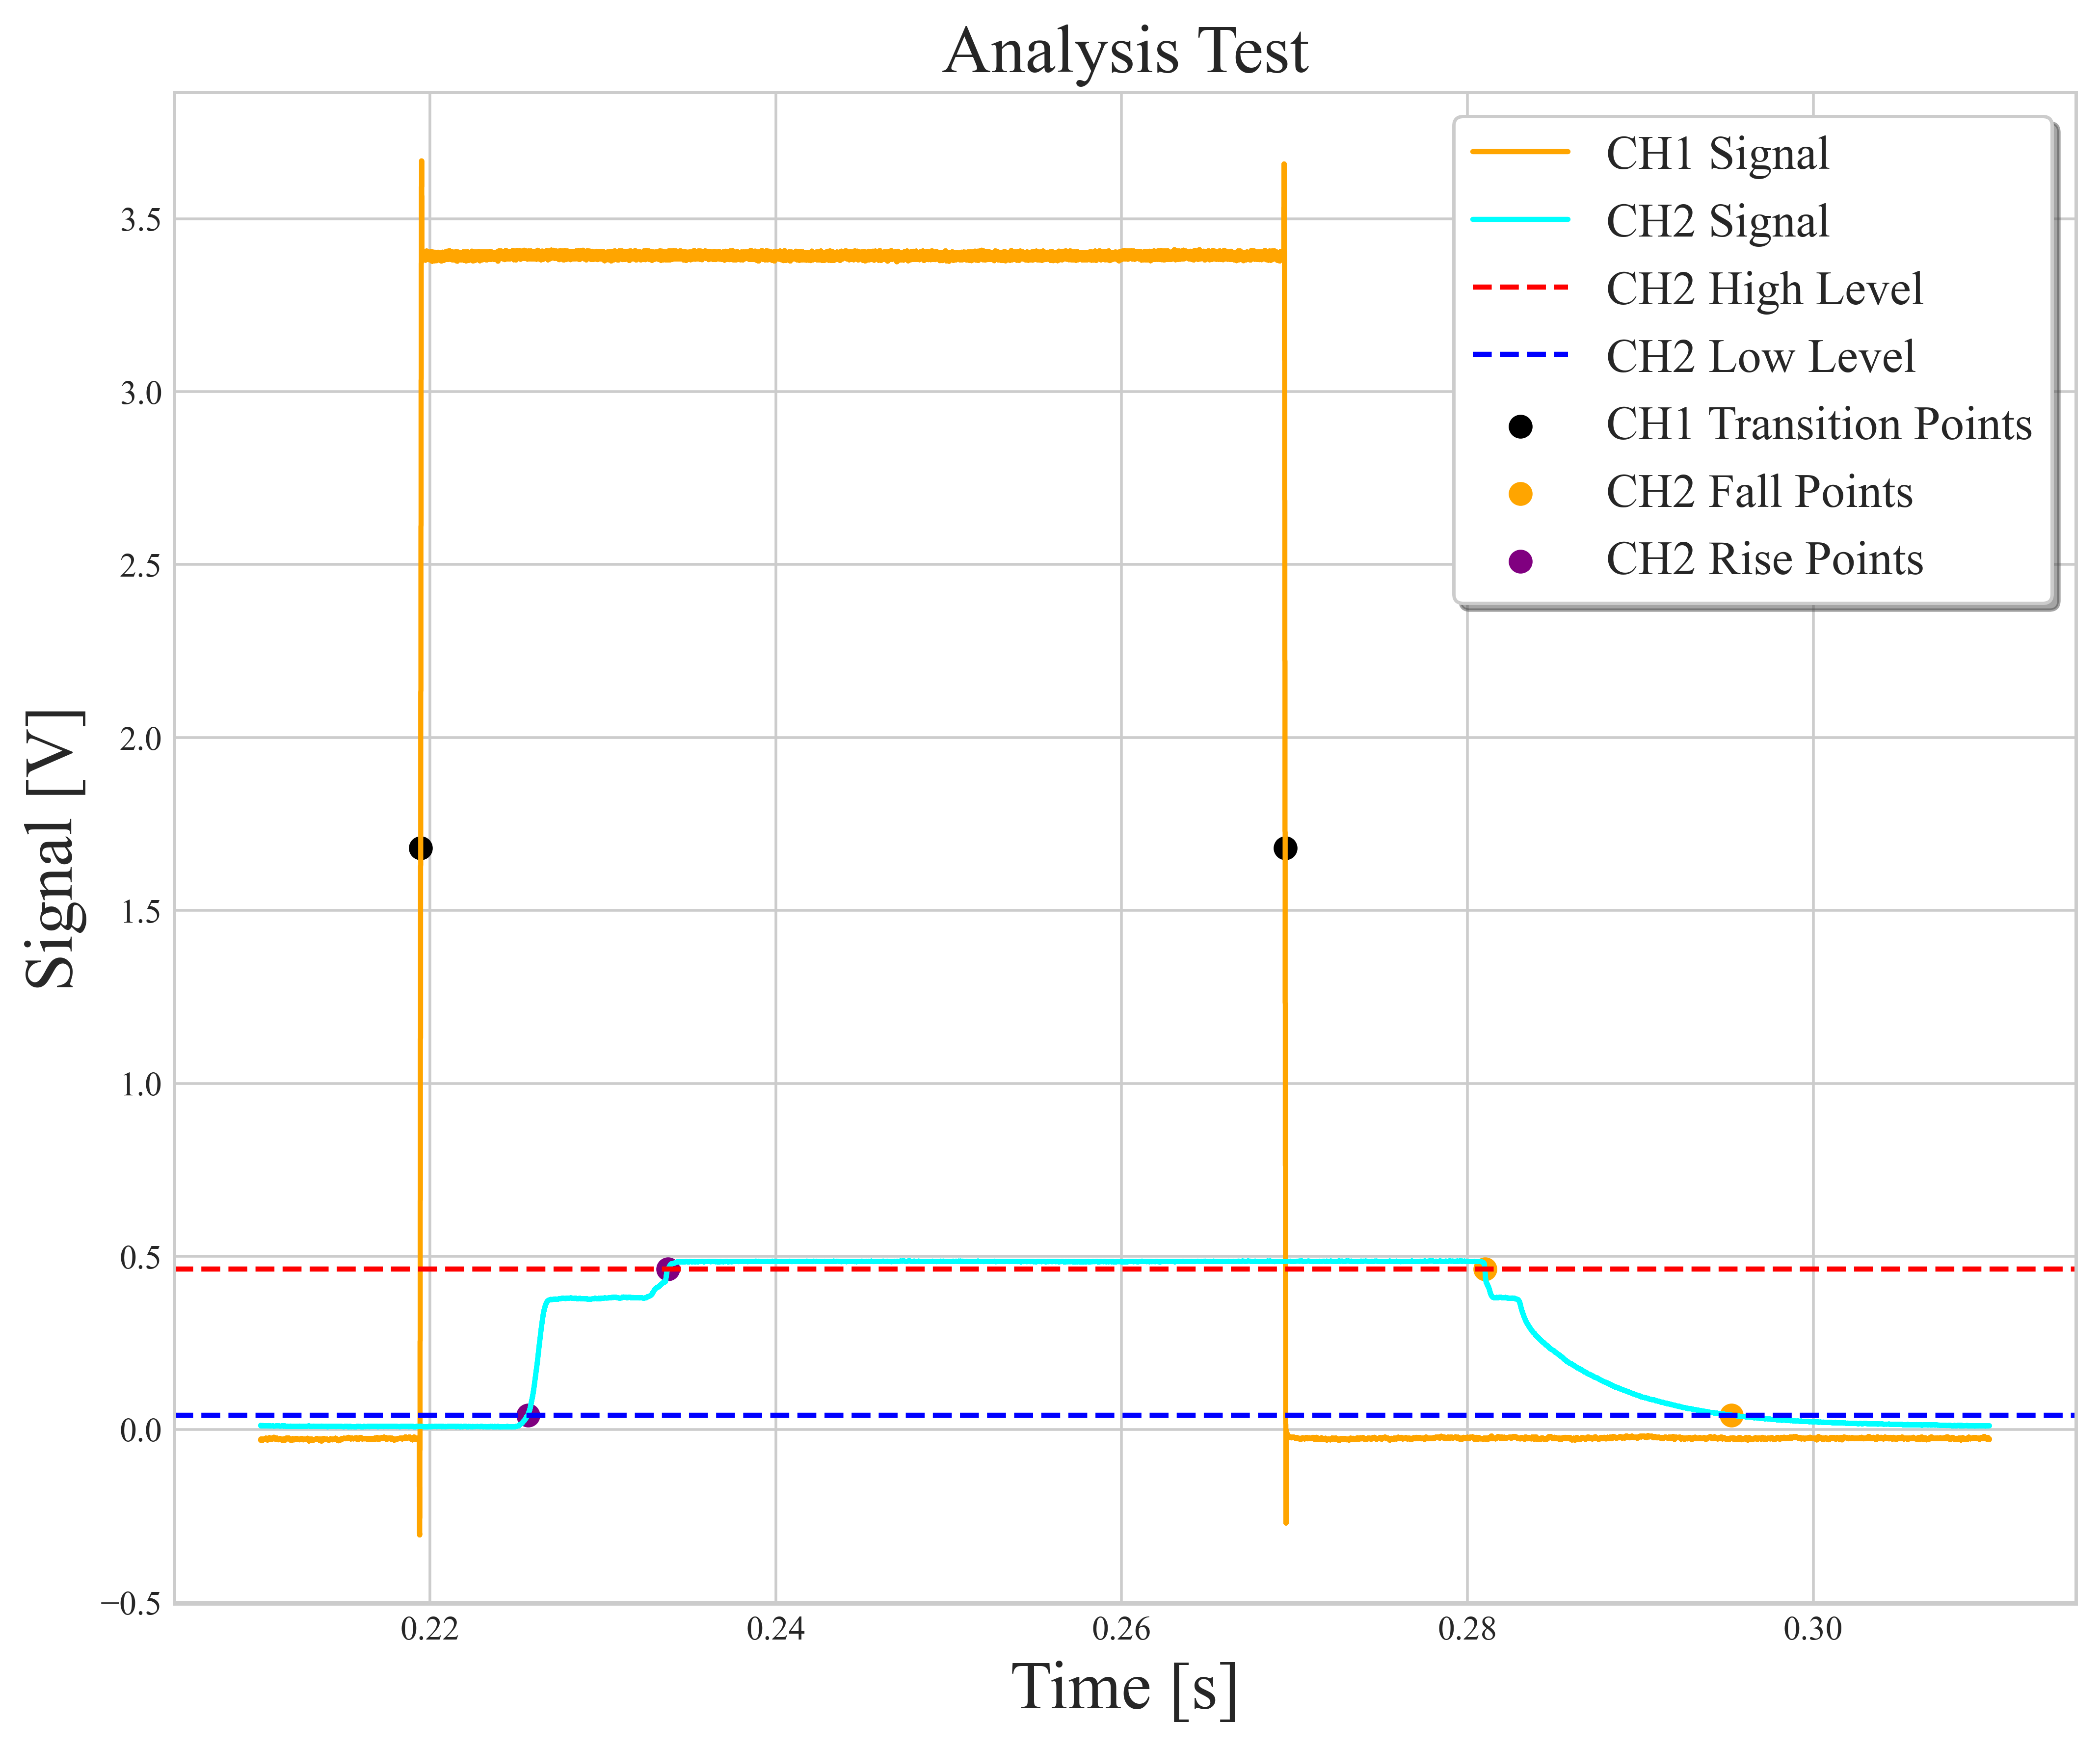

In [29]:
# 可视化信号及标记点
plt.figure()
plt.plot(time, CH1, label="CH1 Signal", color="orange")
plt.plot(time, CH2, label="CH2 Signal", color="cyan")
plt.axhline(CH2_high_level, color="red", linestyle="--", label="CH2 High Level")
plt.axhline(CH2_low_level, color="blue", linestyle="--", label="CH2 Low Level")
plt.scatter([CH1_left_time, CH1_right_time], [CH1_threshold, CH1_threshold], color="black", label="CH1 Transition Points")
plt.scatter([CH2_fall_start_time, CH2_fall_end_time], [CH2_high_level, CH2_low_level], color="orange", label="CH2 Fall Points")
plt.scatter([CH2_rise_start_time, CH2_rise_end_time], [CH2_low_level, CH2_high_level], color="purple", label="CH2 Rise Points")
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.xlabel("Time [s]")
plt.ylabel("Signal [V]")
plt.title("Analysis Test", fontsize=20)
plt.show()


In [ ]:
# 请使用者参考以下示例代码到一个空白的单独的但与其它所有包括数据集和function文件在同一文件夹下的.py文件，最好命名为'ET_proj_analysis_1_main.py'或者'ET_proj_analysis_1_main.ipynb'进行后续数据处理！

# ET_proj_analysis_1_main.ipynb
# 数据处理主程序
# 仅提供一个处理流程的示例

# 导入必要的库
import analysis_1_function as a1f # 特别提醒：数据集要跟main和这个文件在同一文件夹下
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 处理数据（给出各个shutter的散点关系图）
for i in range(1, 6):
    shutter_name = 'shutter'+str(i)
    outcome = a1f.data_integration(shutter_name)
    a1f.main_plot(outcome, label=shutter_name)

# 至于要将各个散点图绘制在一起，以下给出一个粗糙的参考代码，具体可参考a1f.main_plot
plt.figure()
for i in range(1, 6):
    shutter_name = 'shutter'+str(i)
    outcome = a1f.data_integration(shutter_name)
    # 这里只绘制上升响应时间，下降时间类似，自行查看a1f.data_integration给出的数据结构
    plt.sctter(outcome[0], outcome[3], label=shutter_name)
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.xlabel("Voltage [0.1V]")
plt.ylabel("Response Time [s]")
plt.title("Total Scatter Plot", fontsize=20)
plt.show()

# 上述代码大概率出现错误，请先咨询GPT进行修改，若代码整体存在大问题，请通过邮件或者Github的Issue详细描述问题告知我。